Author: Krish

In [1]:
# Importing relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import numpy as np
import warnings
warnings.filterwarnings("ignore")
from datetime import date

In [2]:
data_path = "C:\\Users\\akl0407\\OneDrive - Northwestern University\\Back up\\2025-26\\Spring 2025\\STAT390\\LegalAid\\Data\\CAR_-_EP_Flow_Activity_Queue__Agent_Names\\"
adhoc_data_path = 'C:\\Users\\akl0407\\OneDrive - Northwestern University\\Back up\\2025-26\\Fall 2025\\LegalAid\\Adhoc\\Adhoc datasets\\'

In [3]:
folder = Path(data_path)
files = sorted(list(folder.glob("*.csv")) + list(folder.glob("*.xlsx")))
df_main = pd.DataFrame(columns=['Contact Session ID', 'EP Name', 'Flow Name', 'Activity Name', 'Activity Start Timestamp', 
                                'Queue Name', 'Agent Name', 'Termination Reason'])
df_main

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason


In [4]:
i=0
for f in files:
    i = i + 1
    if f.suffix.lower() == ".csv":
        df = pd.read_csv(f, header=2, dtype=str, engine="python", skip_blank_lines=False)
    else:  # .xlsx
        df = pd.read_excel(f, sheet_name=0, header=2, dtype=str)
    df_main = pd.concat([df_main, df], ignore_index=True)
    print(i, f.stem, df.shape)

1 CAR - EP, Flow, Activity, Queue, & Agent Names (01-12-25 - 01-18-25) (52010, 7)
2 CAR - EP, Flow, Activity, Queue, & Agent Names (01-19-25 - 02-01-25) (95495, 7)
3 CAR - EP, Flow, Activity, Queue, & Agent Names (02-02-25 - 02-15-25) (90056, 7)
4 CAR - EP, Flow, Activity, Queue, & Agent Names (02-16-25 - 03-01-25) (88186, 7)
5 CAR - EP, Flow, Activity, Queue, & Agent Names (03-02-25 - 03-15-25) (86377, 7)
6 CAR - EP, Flow, Activity, Queue, & Agent Names (04-07-24 - 04-20-24) (88766, 7)
7 CAR - EP, Flow, Activity, Queue, & Agent Names (04-21-24 - 05-04-24) (89643, 7)
8 CAR - EP, Flow, Activity, Queue, & Agent Names (05-05-24 - 05-18-24) (82575, 7)
9 CAR - EP, Flow, Activity, Queue, & Agent Names (05-19-24 - 06-01-24) (71103, 7)
10 CAR - EP, Flow, Activity, Queue, & Agent Names (06-02-24 - 06-15-24) (84354, 7)
11 CAR - EP, Flow, Activity, Queue, & Agent Names (06-16-24 - 06-29-24) (82124, 7)
12 CAR - EP, Flow, Activity, Queue, & Agent Names (06-30-24 - 07-13-24) (79752, 7)
13 CAR - EP, 

In [5]:
df_main["Activity Start Timestamp"] = df_main["Activity Start Timestamp"].apply(
    lambda x: datetime.strptime(x, "%Y/%m/%d %I:%M:%S %p"))
df_main["hour"] = df_main["Activity Start Timestamp"].dt.hour
df_main.sort_values(by = ['Contact Session ID', 'Activity Start Timestamp'], inplace=True)
df_main.reset_index(inplace = True, drop = True)

In [6]:
def custdata(id):
    return df_main.loc[df_main['Contact Session ID'] == id,:]
def act_rows(act):
    return df_main.loc[df_main['Activity Name'] == act,:]
def act_data(act):
    get_act_rows = act_rows(act)
    return df_main.loc[df_main['Contact Session ID'].isin(get_act_rows['Contact Session ID']),:]
def data_rows(act, data):
    return data.loc[data['Activity Name'] == act,:]
def col_data(col, val):
    get_col_rows = df_main.loc[df_main[col] == val,:]
    return df_main.loc[df_main['Contact Session ID'].isin(get_col_rows['Contact Session ID']),:]
def col_rows(col, val):
    return df_main.loc[df_main[col] == val,:]
def calls_for_activity(act_name):
    return df_main.loc[df_main['Activity Name'] == act_name,'Contact Session ID'].nunique()
def tagging(data):     
    ids_already_present = data.loc[data['Contact Session ID'].isin(all_data['Contact Session ID']),'Contact Session ID'].nunique()
    print("IDs already present in the previously tagged data = ", ids_already_present)
    data = data.loc[~data['Contact Session ID'].isin(all_data['Contact Session ID']),:]
    print("IDs added = ", data['Contact Session ID'].nunique())    
    print("% IDs added = ", round(100*data['Contact Session ID'].nunique()/248422),"%")
    print("IDs per weekday = ", round(data['Contact Session ID'].nunique()/370))
    appended_data = pd.concat([all_data, data])
    print("IDs in tagged data = ", appended_data['Contact Session ID'].nunique())
    print("% data tagged = ", round(100*appended_data['Contact Session ID'].nunique()/248422),"%")
    return appended_data

In [7]:
df_main_copy = df_main.copy()
df_main_copy = df_main_copy.loc[~df_main['Activity Name'].isna(),:]

#### Main-menu only

In [8]:
num_EPs = df_main.groupby('Contact Session ID')['EP Name'].nunique()
one_ep_data = df_main.loc[df_main['Contact Session ID'].isin(num_EPs[num_EPs == 1].index),:]
main_menu_rows = one_ep_data.loc[one_ep_data['EP Name'] == 'Main Number Telephony EP',:]
main_menu_data = df_main.loc[df_main['Contact Session ID'].isin(main_menu_rows['Contact Session ID']),:]

num_acts = df_main.groupby('Contact Session ID')['Activity Name'].nunique()
no_acts_rem = df_main.loc[(df_main['Contact Session ID'].isin(num_acts[(num_acts == 0)].index)) & \
(df_main['EP Name'] == 'Pre-Legal Menu Seniors Menu Telephony EP'),:]
no_acts_rem_data = df_main.loc[df_main['Contact Session ID'].isin(no_acts_rem['Contact Session ID']),:]

main_menu_data = pd.concat([main_menu_data, no_acts_rem_data])
main_menu_data['caller_type'] = 'Main menu only'
print("% data = ", round(100*98352/248422),"%")
print("calls per day = ", round(98352/370))
print("calls per day = ",main_menu_data['Contact Session ID'].nunique())

% data =  40 %
calls per day =  266
calls per day =  98357


## closed hours

In [9]:
closed_hours_data = col_data('EP Name', 'Closed Hours-Holidays Menu Telephony EP')
closed_hours_data['caller_type'] = 'Closed hours callers'
print(closed_hours_data['Contact Session ID'].nunique())

ids1 = set(main_menu_data["Contact Session ID"])
ids2 = set(closed_hours_data["Contact Session ID"])
common_12 = ids1 & ids2
if len(common_12) == 0:
    print("No overlap with the previously tagged data")

all_data = pd.concat([main_menu_data,closed_hours_data])
print("% data = ", round(100*closed_hours_data['Contact Session ID'].nunique()/248422),"%")
print("calls per day = ", round(closed_hours_data['Contact Session ID'].nunique()/370))
all_data['Contact Session ID'].nunique()

21861
No overlap with the previously tagged data
% data =  9 %
calls per day =  59


120218

### Farmworker data
calls already tagged as during closed hours excluded
Removing farmworker data from analysis due to high abandonment rate

In [10]:
farm_data = act_data('FarmworkerMainMenu')
farmworker_rows = one_ep_data.loc[one_ep_data['EP Name'] == 'Farmworker Main Number Telephony EP',:]
farmworker_data = df_main.loc[df_main['Contact Session ID'].isin(farmworker_rows['Contact Session ID']),:]
more_farm_data = farmworker_data.loc[~farmworker_data['Contact Session ID'].isin(farm_data['Contact Session ID']),:]
farm_data = pd.concat([farm_data, more_farm_data])
farm_data['caller_type'] = 'Farmworker'
all_data = tagging(farm_data)

IDs already present in the previously tagged data =  90
IDs added =  10310
% IDs added =  4 %
IDs per weekday =  28
IDs in tagged data =  130528
% data tagged =  53 %


### Non-seniors legal menu
Calls that reach LegalMenu2, but never reach SuburbsOrCityMenu

In [11]:
legmen2_data = act_data('LegalMenu1')
leg_senior_data_rows = data_rows('SuburbsOrCityMenu',legmen2_data)
#Non-seniors never reach the suburbs or city menu
leg_non_senior_data = legmen2_data.loc[~legmen2_data['Contact Session ID'].isin(leg_senior_data_rows['Contact Session ID']),:]
leg_non_senior_data['caller_type'] = 'Non-senior legal issue'
all_data = tagging(leg_non_senior_data)

IDs already present in the previously tagged data =  581
IDs added =  79085
% IDs added =  32 %
IDs per weekday =  214
IDs in tagged data =  209613
% data tagged =  84 %


## Seniors
### Suburban seniors
Calls that reach SuburbanSeniorsMenu menu

In [12]:
suburban_seniors_data = act_data('SuburbanSeniorsMenu')
suburban_seniors_data['caller_type'] = 'Suburban senior'
all_data = tagging(suburban_seniors_data)

IDs already present in the previously tagged data =  14
IDs added =  8305
% IDs added =  3 %
IDs per weekday =  22
IDs in tagged data =  217918
% data tagged =  88 %


### City Seniors

In [13]:
city_seniors = act_data('SeniorsADAPTMenu')
city_seniors['caller_type'] = 'Chicago senior'
all_data = tagging(city_seniors)

IDs already present in the previously tagged data =  55
IDs added =  17975
% IDs added =  7 %
IDs per weekday =  49
IDs in tagged data =  235893
% data tagged =  95 %


### Non cook county seniors

In [14]:
noncook_seniors = act_data('SeniorNotCookCoMenu')
noncook_seniors['caller_type'] = 'Non-Cook County Senior'
all_data = tagging(noncook_seniors)

IDs already present in the previously tagged data =  10
IDs added =  1302
% IDs added =  1 %
IDs per weekday =  4
IDs in tagged data =  237195
% data tagged =  95 %



### Unclassified seniors

In [15]:
#unclassified_seniors = act_data('SuburbsOrCityMenu')
#unclassified_seniors['caller_type'] = 'Unclassified seniors'
#all_data = tagging(unclassified_seniors)

All these seniors abandoned call before making a choice

## Intake outdial EP

In [16]:
intake_rows = one_ep_data.loc[one_ep_data['EP Name'] == 'Intake Outdial EP',:]
intake_outdial_data = df_main.loc[df_main['Contact Session ID'].isin(intake_rows['Contact Session ID']),:]
intake_outdial_data['caller_type'] = 'Intake Outdial'
all_data = tagging(intake_outdial_data)

IDs already present in the previously tagged data =  0
IDs added =  9395
% IDs added =  4 %
IDs per weekday =  25
IDs in tagged data =  246590
% data tagged =  99 %


### Rest

In [17]:
rest_data = df_main.loc[~df_main['Contact Session ID'].isin(all_data['Contact Session ID']),:]

In [18]:
rest_data_nomissact = rest_data.loc[~rest_data['Activity Name'].isna(),:]
last_act = rest_data_nomissact.groupby('Contact Session ID').tail(1)[['Contact Session ID', 'Activity Name']]
rest_data_nomissact.groupby('Contact Session ID').tail(1)[['Activity Name']].value_counts()

Activity Name          
SeniorsMenu                1197
SuburbsOrCityMenu           443
SeniorsConfirmationMenu     211
MainMenu                      1
Name: count, dtype: int64

All these calls are abandoned before information about the caller was obtained

In [19]:
rest_data['caller_type'] = 'unclassified (with access to legal issues menu)'
all_data = tagging(rest_data)

IDs already present in the previously tagged data =  0
IDs added =  1852
% IDs added =  1 %
IDs per weekday =  5
IDs in tagged data =  248442
% data tagged =  100 %


### caller type summary

In [20]:
call_type = pd.DataFrame({'calls':all_data.groupby('caller_type')['Contact Session ID'].nunique().sort_values(ascending = False)})
call_type['percent_calls'] = round(100*call_type['calls'] / 248442)
call_type['calls_per_weekday'] = round(call_type['calls'] / 370)
call_type

,calls,percent_calls,calls_per_weekday
caller_type,,,
Main menu only,98357,40.0,266.0
Non-senior legal issue,79085,32.0,214.0
Closed hours callers,21861,9.0,59.0
Chicago senior,17975,7.0,49.0
Farmworker,10310,4.0,28.0
Intake Outdial,9395,4.0,25.0
Suburban senior,8305,3.0,22.0
unclassified (with access to legal issues menu),1852,1.0,5.0
Non-Cook County Senior,1302,1.0,4.0


In [23]:
all_data['Overall_tag'] = "Legal issue"
all_data.loc[all_data['caller_type'].isin(['Farmworker','Intake Outdial','Closed hours callers']),'Overall_tag'] = 'Other'
all_data.loc[all_data['caller_type'] == 'Main menu only','Overall_tag'] = 'Main menu'
call_type = pd.DataFrame({'calls':all_data.groupby('Overall_tag')['Contact Session ID'].nunique().sort_values(ascending = False)})
call_type['percent_calls'] = round(100*call_type['calls'] / 248442)
call_type['calls_per_weekday'] = round(call_type['calls'] / 370)
call_type

,calls,percent_calls,calls_per_weekday
Overall_tag,,,
Legal issue,108519,44.0,293.0
Main menu,98357,40.0,266.0
Other,41566,17.0,112.0


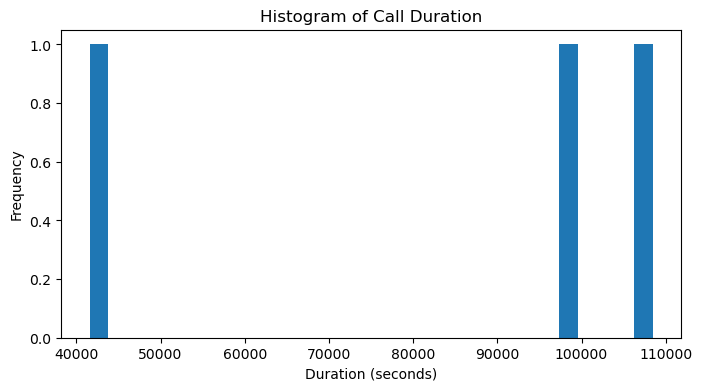

In [22]:
#import matplotlib.pyplot as plt

# Histogram
plt.figure(figsize=(8, 4))
plt.hist(call_type["calls"], bins=30)
plt.xlabel("Duration (seconds)")
plt.ylabel("Frequency")
plt.title("Histogram of Call Duration")
plt.show()




In [87]:
last_act = all_data.loc[~all_data['Activity Name'].isna(),:].groupby('Contact Session ID').tail(1)
no_act_csid = all_data.loc[~all_data['Contact Session ID'].isin(last_act['Contact Session ID']),:]
no_act_csid_last_row = no_act_csid.groupby('Contact Session ID').tail(1)
no_act_csid_last_row['Activity Name'] = 'No activity'

last_act = pd.concat([last_act, no_act_csid_last_row])

last_act.loc[last_act['Activity Name'] == 'OtherLegalMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'OtherLegalMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'OtherLegalMenu', 'outcome_source'] ='OtherLegalMenu'
olm_in_other = df_main.loc[df_main['Activity Name'].isin(['OtherLegalPersonalInjuryMenu','OtherLegalCriminalCaseMenu','OtherLegalOtherMenu']),:]
last_act.loc[(last_act['Activity Name'] == 'OtherLegalMenu') & (last_act['Contact Session ID'].isin(olm_in_other['Contact Session ID'])), 'outcome'] = 'Neutral'
last_act.loc[(last_act['Activity Name'] == 'OtherLegalMenu') & (last_act['Contact Session ID'].isin(olm_in_other['Contact Session ID'])), 'outcome_type'] = 'LAC does not serve'
last_act.loc[(last_act['Activity Name'] == 'OtherLegalMenu') & (last_act['Contact Session ID'].isin(olm_in_other['Contact Session ID'])), 'outcome_source'] = 'OtherLegalMenu'

last_act.loc[last_act['Activity Name'] == 'ClosedQueueMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'ClosedQueueMenu', 'outcome_type'] ='Closed queue'
last_act.loc[last_act['Activity Name'] == 'ClosedQueueMenu', 'outcome_source'] ='ClosedQueueMenu'
last_act.loc[last_act['Activity Name'] == 'StaffDirectoryEnglishTransfer', 'outcome'] = 'Positive'
last_act.loc[last_act['Activity Name'] == 'StaffDirectoryEnglishTransfer', 'outcome_type'] ='Staff directory'
last_act.loc[last_act['Activity Name'] == 'StaffDirectoryEnglishTransfer', 'outcome_source'] ='StaffDirectoryEnglishTransfer'
last_act.loc[last_act['Activity Name'] == 'LanguageSelectionMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'LanguageSelectionMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'LanguageSelectionMenu', 'outcome_source'] ='LanguageSelectionMenu'

last_act.loc[(last_act['Activity Name'] == 'ClinicVoicemailTransfer') & (last_act['EP Name'] == 'Closed Queue Menu Telephony EP'), 'outcome'] = 'Negative'
last_act.loc[(last_act['Activity Name'] == 'ClinicVoicemailTransfer') & (last_act['EP Name'] == 'Closed Queue Menu Telephony EP'), 'outcome_type'] ='Closed queue'
last_act.loc[(last_act['Activity Name'] == 'ClinicVoicemailTransfer') & (last_act['EP Name'] == 'Closed Queue Menu Telephony EP'), 'outcome_source'] ='ClinicVoicemailTransfer (Closed Queue EP)'

last_act.loc[(last_act['Activity Name'] == 'ClinicVoicemailTransfer') & (last_act['EP Name'] == 'Closed Hours-Holidays Menu Telephony EP'), 'outcome'] = 'Neutral'
last_act.loc[(last_act['Activity Name'] == 'ClinicVoicemailTransfer') & (last_act['EP Name'] == 'Closed Hours-Holidays Menu Telephony EP'), 'outcome_type'] ='Closed hours'
last_act.loc[(last_act['Activity Name'] == 'ClinicVoicemailTransfer') & (last_act['EP Name'] == 'Closed Hours-Holidays Menu Telephony EP'), 'outcome_source'] ='ClinicVoicemailTransfer (Closed hours EP)'

last_act.loc[(last_act['Activity Name'] == 'ClinicVoicemailTransfer') & (last_act['outcome'].isna()), 'outcome'] = 'Positive'
last_act.loc[(last_act['Activity Name'] == 'ClinicVoicemailTransfer') & (last_act['outcome_type'].isna()), 'outcome_type'] ='Clinic voicemail'
last_act.loc[(last_act['Activity Name'] == 'ClinicVoicemailTransfer') & (last_act['outcome_source'].isna()), 'outcome_source'] ='ClinicVoicemailTransfer'

last_act.loc[last_act['Activity Name'] == 'MainMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'MainMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'MainMenu', 'outcome_source'] ='MainMenu'

last_act.loc[(last_act['Activity Name'] == 'DisconnectContact1') & (last_act['EP Name'] == 'Closed Queue Menu Telephony EP'), 'outcome'] = 'Negative'
last_act.loc[(last_act['Activity Name'] == 'DisconnectContact1') & (last_act['EP Name'] == 'Closed Queue Menu Telephony EP'), 'outcome_type'] ='Closed queue'
last_act.loc[(last_act['Activity Name'] == 'DisconnectContact1') & (last_act['EP Name'] == 'Closed Queue Menu Telephony EP'), 'outcome_source'] ='DisconnectContact1 (Closed Queue EP)'

last_act.loc[(last_act['Activity Name'] == 'DisconnectContact1') & (last_act['EP Name'] == 'Closed Hours-Holidays Menu Telephony EP'), 'outcome'] = 'Neutral'
last_act.loc[(last_act['Activity Name'] == 'DisconnectContact1') & (last_act['EP Name'] == 'Closed Hours-Holidays Menu Telephony EP'), 'outcome_type'] ='Closed hours'
last_act.loc[(last_act['Activity Name'] == 'DisconnectContact1') & (last_act['EP Name'] == 'Closed Hours-Holidays Menu Telephony EP'), 'outcome_source'] ='DisconnectContact1 (Closed hours EP)'

last_act.loc[(last_act['Activity Name'] == 'DisconnectContact1') & (last_act['EP Name'] == 'Pre-Legal Menu Seniors Menu Telephony EP'), 'outcome'] = 'Neutral'
last_act.loc[(last_act['Activity Name'] == 'DisconnectContact1') & (last_act['EP Name'] == 'Pre-Legal Menu Seniors Menu Telephony EP'), 'outcome_type'] ='LAC does not serve'
last_act.loc[(last_act['Activity Name'] == 'DisconnectContact1') & (last_act['EP Name'] == 'Pre-Legal Menu Seniors Menu Telephony EP'), 'outcome_source'] ='DisconnectContact1 (Pre-legal Seniors EP)'

last_act.loc[(last_act['Activity Name'] == 'DisconnectContact1') & (last_act['EP Name'] == 'Courtesy Callback Telephony EP'), 'outcome'] = 'Negative'
last_act.loc[(last_act['Activity Name'] == 'DisconnectContact1') & (last_act['EP Name'] == 'Courtesy Callback Telephony EP'), 'outcome_type'] ='Failed courtsey callback'
last_act.loc[(last_act['Activity Name'] == 'DisconnectContact1') & (last_act['EP Name'] == 'Courtesy Callback Telephony EP'), 'outcome_source'] ='DisconnectContact1 (callback EP)'

last_act.loc[last_act['Activity Name'] == 'LegalMenu2', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'LegalMenu2', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'LegalMenu2', 'outcome_source'] ='LegalMenu2'
last_act.loc[last_act['Activity Name'] == 'FarmworkerMainMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'FarmworkerMainMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'FarmworkerMainMenu', 'outcome_source'] ='FarmworkerMainMenu'
last_act.loc[last_act['Activity Name'] == 'SetCallerID', 'outcome'] = 'Positive'
last_act.loc[last_act['Activity Name'] == 'SetCallerID', 'outcome_type'] ='Connected to agent'
last_act.loc[last_act['Activity Name'] == 'SetCallerID', 'outcome_source'] ='SetCallerID'
last_act.loc[last_act['Activity Name'] == 'LegalServerScreenPop', 'outcome'] = 'Positive'
last_act.loc[last_act['Activity Name'] == 'LegalServerScreenPop', 'outcome_type'] ='Connected to agent'
last_act.loc[last_act['Activity Name'] == 'LegalServerScreenPop', 'outcome_source'] ='LegalServerScreenPop'
last_act.loc[last_act['Activity Name'] == 'FrontDeskTransfer1', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'FrontDeskTransfer1', 'outcome_type'] ='No language selected (FD1)'
last_act.loc[last_act['Activity Name'] == 'FrontDeskTransfer1', 'outcome_source'] ='FrontDeskTransfer1'
last_act.loc[last_act['Activity Name'] == 'ClosedMenu', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'ClosedMenu', 'outcome_type'] ='Closed hours'
last_act.loc[last_act['Activity Name'] == 'ClosedMenu', 'outcome_source'] ='ClosedMenu'
last_act.loc[last_act['Activity Name'] == 'FrontDeskTransfer2', 'outcome'] = 'Positive'
last_act.loc[last_act['Activity Name'] == 'FrontDeskTransfer2', 'outcome_type'] ='Appt / feedback'
last_act.loc[last_act['Activity Name'] == 'FrontDeskTransfer2', 'outcome_source'] ='FrontDeskTransfer2'

last_act.loc[last_act['Activity Name'] == 'StaffDirectorySpanishTransfer', 'outcome'] = 'Positive'
last_act.loc[last_act['Activity Name'] == 'StaffDirectorySpanishTransfer', 'outcome_type'] ='Staff directory'
last_act.loc[last_act['Activity Name'] == 'StaffDirectorySpanishTransfer', 'outcome_source'] ='StaffDirectorySpanishTransfer'
last_act.loc[last_act['Activity Name'] == 'FrontDeskTransfer', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'FrontDeskTransfer', 'outcome_type'] ='Interpreter needed (FD, Legal menu)'
last_act.loc[last_act['Activity Name'] == 'FrontDeskTransfer', 'outcome_source'] ='FrontDeskTransfer'
last_act.loc[last_act['Activity Name'] == 'TenantMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'TenantMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'TenantMenu', 'outcome_source'] ='TenantMenu'
last_act.loc[last_act['Activity Name'] == 'CriminalRecordsVoicemailTransfer', 'outcome'] = 'Positive'
last_act.loc[last_act['Activity Name'] == 'CriminalRecordsVoicemailTransfer', 'outcome_type'] ='Criminal Voicemail'
last_act.loc[last_act['Activity Name'] == 'CriminalRecordsVoicemailTransfer', 'outcome_source'] ='CriminalRecordsVoicemailTransfer'
last_act.loc[last_act['Activity Name'] == 'OtherLegalOtherMenu', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'OtherLegalOtherMenu', 'outcome_type'] ='LAC does not serve'
last_act.loc[last_act['Activity Name'] == 'OtherLegalOtherMenu', 'outcome_source'] ='OtherLegalOtherMenu'
last_act.loc[last_act['Activity Name'] == 'DivorceOrParentingMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'DivorceOrParentingMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'DivorceOrParentingMenu', 'outcome_source'] ='DivorceOrParentingMenu'
last_act.loc[last_act['Activity Name'] == 'QueueMenu1', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'QueueMenu1', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'QueueMenu1', 'outcome_source'] ='QueueMenu1'
last_act.loc[last_act['Activity Name'] == 'LegalMenu1', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'LegalMenu1', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'LegalMenu1', 'outcome_source'] ='LegalMenu1'
last_act.loc[last_act['Activity Name'] == 'SeniorsMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'SeniorsMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'SeniorsMenu', 'outcome_source'] ='SeniorsMenu'
last_act.loc[last_act['Activity Name'] == 'TenantDeterrenceMenu', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'TenantDeterrenceMenu', 'outcome_type'] ='LAC does not serve'
last_act.loc[last_act['Activity Name'] == 'TenantDeterrenceMenu', 'outcome_source'] ='TenantDeterrenceMenu'
last_act.loc[last_act['Activity Name'] == 'HousingMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'HousingMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'HousingMenu', 'outcome_source'] ='HousingMenu'
last_act.loc[last_act['Activity Name'] == 'HIVVoicemailTransfer', 'outcome'] = 'Positive'
last_act.loc[last_act['Activity Name'] == 'HIVVoicemailTransfer', 'outcome_type'] ='HIV Voicemail'
last_act.loc[last_act['Activity Name'] == 'HIVVoicemailTransfer', 'outcome_source'] ='HIVVoicemailTransfer'
last_act.loc[last_act['Activity Name'] == 'PlayMOH300s', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'PlayMOH300s', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'PlayMOH300s', 'outcome_source'] ='PlayMOH300s'
last_act.loc[last_act['Activity Name'] == 'HIVMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'HIVMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'HIVMenu', 'outcome_source'] ='HIVMenu'
last_act.loc[last_act['Activity Name'] == 'ScreenPopProcessComplete', 'outcome'] = 'Positive'
last_act.loc[last_act['Activity Name'] == 'ScreenPopProcessComplete', 'outcome_type'] ='Connected to agent'
last_act.loc[last_act['Activity Name'] == 'ScreenPopProcessComplete', 'outcome_source'] ='ScreenPopProcessComplete'
last_act.loc[last_act['Activity Name'] == 'AddressFaxHoursMenu', 'outcome'] = 'Positive'
last_act.loc[last_act['Activity Name'] == 'AddressFaxHoursMenu', 'outcome_type'] ='Address Voicemail'
last_act.loc[last_act['Activity Name'] == 'AddressFaxHoursMenu', 'outcome_source'] ='AddressFaxHoursMenu'
last_act.loc[last_act['Activity Name'] == 'PreTenantMenu', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'PreTenantMenu', 'outcome_type'] ='LAC does not serve'
last_act.loc[last_act['Activity Name'] == 'PreTenantMenu', 'outcome_source'] ='PreTenantMenu'
last_act.loc[last_act['Activity Name'] == 'FamilyMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'FamilyMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'FamilyMenu', 'outcome_source'] ='FamilyMenu'
last_act.loc[last_act['Activity Name'] == 'FrontDeskTransfer3', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'FrontDeskTransfer3', 'outcome_type'] ='No selection on Main menu (FD3)'
last_act.loc[last_act['Activity Name'] == 'FrontDeskTransfer3', 'outcome_source'] ='FrontDeskTransfer3'
last_act.loc[last_act['Activity Name'] == 'ChildSupportMenu', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'ChildSupportMenu', 'outcome_type'] ='LAC does not serve'
last_act.loc[last_act['Activity Name'] == 'ChildSupportMenu', 'outcome_source'] ='ChildSupportMenu'
last_act.loc[last_act['Activity Name'] == 'ImmigrationMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'ImmigrationMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'ImmigrationMenu', 'outcome_source'] ='ImmigrationMenu'
last_act.loc[last_act['Activity Name'] == 'SeniorsADAPTMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'SeniorsADAPTMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'SeniorsADAPTMenu', 'outcome_source'] ='SeniorsADAPTMenu'
last_act.loc[last_act['Activity Name'] == 'OtherLegalPersonalInjuryMenu', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'OtherLegalPersonalInjuryMenu', 'outcome_type'] ='LAC does not serve'
last_act.loc[last_act['Activity Name'] == 'OtherLegalPersonalInjuryMenu', 'outcome_source'] ='OtherLegalPersonalInjuryMenu'
last_act.loc[last_act['Activity Name'] == 'OtherLegalCriminalCaseMenu', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'OtherLegalCriminalCaseMenu', 'outcome_type'] ='LAC does not serve'
last_act.loc[last_act['Activity Name'] == 'OtherLegalCriminalCaseMenu', 'outcome_source'] ='OtherLegalCriminalCaseMenu'
last_act.loc[last_act['Activity Name'] == 'SuburbsOrCityMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'SuburbsOrCityMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'SuburbsOrCityMenu', 'outcome_source'] ='SuburbsOrCityMenu'
last_act.loc[last_act['Activity Name'] == 'SuburbanSeniorsMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'SuburbanSeniorsMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'SuburbanSeniorsMenu', 'outcome_source'] ='SuburbanSeniorsMenu'
last_act.loc[last_act['Activity Name'] == 'TransferToSafeHaven', 'outcome'] = 'Positive'
last_act.loc[last_act['Activity Name'] == 'TransferToSafeHaven', 'outcome_type'] ='Chatbot experiment (Family menu)'
last_act.loc[last_act['Activity Name'] == 'TransferToSafeHaven', 'outcome_source'] ='TransferToSafeHaven'
last_act.loc[last_act['Activity Name'] == 'SimpleDivorceMenu', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'SimpleDivorceMenu', 'outcome_type'] ='LAC does not serve'
last_act.loc[last_act['Activity Name'] == 'SimpleDivorceMenu', 'outcome_source'] ='SimpleDivorceMenu'
last_act.loc[last_act['Activity Name'] == 'BenefitsMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'BenefitsMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'BenefitsMenu', 'outcome_source'] ='BenefitsMenu'
last_act.loc[last_act['Activity Name'] == 'SubSeniorPreQueueMessage1_1', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'SubSeniorPreQueueMessage1_1', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'SubSeniorPreQueueMessage1_1', 'outcome_source'] ='SubSeniorPreQueueMessage1_1'
last_act.loc[last_act['Activity Name'] == 'ThankYouGoodbye', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'ThankYouGoodbye', 'outcome_type'] ='LAC does not serve'
last_act.loc[last_act['Activity Name'] == 'ThankYouGoodbye', 'outcome_source'] ='ThankYouGoodbye'
last_act.loc[last_act['Activity Name'] == 'IntakePreQueueMessage1', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'IntakePreQueueMessage1', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'IntakePreQueueMessage1', 'outcome_source'] ='IntakePreQueueMessage1'
last_act.loc[last_act['Activity Name'] == 'SeniorsConfirmationMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'SeniorsConfirmationMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'SeniorsConfirmationMenu', 'outcome_source'] ='SeniorsConfirmationMenu'
last_act.loc[last_act['Activity Name'] == 'VeteransBenefitsVoicemailTransfer', 'outcome'] = 'Positive'
last_act.loc[last_act['Activity Name'] == 'VeteransBenefitsVoicemailTransfer', 'outcome_type'] ='Veterans Voicemail'
last_act.loc[last_act['Activity Name'] == 'VeteransBenefitsVoicemailTransfer', 'outcome_source'] ='VeteransBenefitsVoicemailTransfer'
last_act.loc[last_act['Activity Name'] == 'EmploymentMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'EmploymentMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'EmploymentMenu', 'outcome_source'] ='EmploymentMenu'
last_act.loc[last_act['Activity Name'] == 'No activity', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'No activity', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'No activity', 'outcome_source'] ='No activity'
last_act.loc[last_act['Activity Name'] == 'DisconnectContact2', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'DisconnectContact2', 'outcome_type'] ='LAC does not serve'
last_act.loc[last_act['Activity Name'] == 'DisconnectContact2', 'outcome_source'] ='DisconnectContact2'
last_act.loc[last_act['Activity Name'] == 'TraffickingVoicemailTransfer', 'outcome'] = 'Positive'
last_act.loc[last_act['Activity Name'] == 'TraffickingVoicemailTransfer', 'outcome_type'] ='Trafficking Voicemail'
last_act.loc[last_act['Activity Name'] == 'TraffickingVoicemailTransfer', 'outcome_source'] ='TraffickingVoicemailTransfer'
last_act.loc[last_act['Activity Name'] == 'AppointmentMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'AppointmentMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'AppointmentMenu', 'outcome_source'] ='AppointmentMenu'
last_act.loc[last_act['Activity Name'] == 'SeniorNotCookCoMenu', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'SeniorNotCookCoMenu', 'outcome_type'] ='LAC does not serve'
last_act.loc[last_act['Activity Name'] == 'SeniorNotCookCoMenu', 'outcome_source'] ='SeniorNotCookCoMenu'
last_act.loc[last_act['Activity Name'] == 'ImmigrationOtherMenu', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'ImmigrationOtherMenu', 'outcome_type'] ='LAC does not serve'
last_act.loc[last_act['Activity Name'] == 'ImmigrationOtherMenu', 'outcome_source'] ='ImmigrationOtherMenu'
last_act.loc[last_act['Activity Name'] == 'HolidayPrompt', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'HolidayPrompt', 'outcome_type'] ='Closed hours'
last_act.loc[last_act['Activity Name'] == 'HolidayPrompt', 'outcome_source'] ='HolidayPrompt'
last_act.loc[last_act['Activity Name'] == 'DisconnectCallbackContact', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'DisconnectCallbackContact', 'outcome_type'] ='Failed courtsey callback'
last_act.loc[last_act['Activity Name'] == 'DisconnectCallbackContact', 'outcome_source'] ='DisconnectCallbackContact'
last_act.loc[last_act['Activity Name'] == 'MigrantVoicemailTransfer', 'outcome'] = 'Positive'
last_act.loc[last_act['Activity Name'] == 'MigrantVoicemailTransfer', 'outcome_type'] ='Farmworker Voicemail'
last_act.loc[last_act['Activity Name'] == 'MigrantVoicemailTransfer', 'outcome_source'] ='MigrantVoicemailTransfer'
last_act.loc[last_act['Activity Name'] == 'ComplimentOrComplaintMenu', 'outcome'] = 'Positive'
last_act.loc[last_act['Activity Name'] == 'ComplimentOrComplaintMenu', 'outcome_type'] ='Feedback'
last_act.loc[last_act['Activity Name'] == 'ComplimentOrComplaintMenu', 'outcome_source'] ='ComplimentOrComplaintMenu'
last_act.loc[last_act['Activity Name'] == 'PreQueueMessage2', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'PreQueueMessage2', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'PreQueueMessage2', 'outcome_source'] ='PreQueueMessage2'
last_act.loc[last_act['Activity Name'] == 'HelpWithLegalorOtherReasonMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'HelpWithLegalorOtherReasonMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'HelpWithLegalorOtherReasonMenu', 'outcome_source'] ='HelpWithLegalorOtherReasonMenu'
last_act.loc[last_act['Activity Name'] == 'DisconnectContact', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'DisconnectContact', 'outcome_type'] ='Outbound call failed'
last_act.loc[last_act['Activity Name'] == 'DisconnectContact', 'outcome_source'] ='DisconnectContact'
last_act.loc[last_act['Activity Name'] == 'WorkersCompMenu', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'WorkersCompMenu', 'outcome_type'] ='LAC does not serve'
last_act.loc[last_act['Activity Name'] == 'WorkersCompMenu', 'outcome_source'] ='WorkersCompMenu'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInSubSeniorTenantAgents', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInSubSeniorTenantAgents', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInSubSeniorTenantAgents', 'outcome_source'] ='GetLoggedInSubSeniorTenantAgents'
last_act.loc[last_act['Activity Name'] == 'ReadANI', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'ReadANI', 'outcome_type'] ='Failed courtsey callback'
last_act.loc[last_act['Activity Name'] == 'ReadANI', 'outcome_source'] ='ReadANI'
last_act.loc[last_act['Activity Name'] == 'PlayErrorMessage', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'PlayErrorMessage', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'PlayErrorMessage', 'outcome_source'] ='PlayErrorMessage'
last_act.loc[last_act['Activity Name'] == 'CallbackRetry', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'CallbackRetry', 'outcome_type'] ='Failed courtsey callback'
last_act.loc[last_act['Activity Name'] == 'CallbackRetry', 'outcome_source'] ='CallbackRetry'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInSubSeniorOtherAgents', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInSubSeniorOtherAgents', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInSubSeniorOtherAgents', 'outcome_source'] ='GetLoggedInSubSeniorOtherAgents'
last_act.loc[last_act['Activity Name'] == 'CollectCallbackNumber', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'CollectCallbackNumber', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'CollectCallbackNumber', 'outcome_source'] ='CollectCallbackNumber'
last_act.loc[last_act['Activity Name'] == 'ConfirmCallbackNumber', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'ConfirmCallbackNumber', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'ConfirmCallbackNumber', 'outcome_source'] ='ConfirmCallbackNumber'
last_act.loc[last_act['Activity Name'] == 'SubSeniorPreQueueMessage1_2', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'SubSeniorPreQueueMessage1_2', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'SubSeniorPreQueueMessage1_2', 'outcome_source'] ='SubSeniorPreQueueMessage1_2'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInSubSeniorOtherSPAgents', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInSubSeniorOtherSPAgents', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInSubSeniorOtherSPAgents', 'outcome_source'] ='GetLoggedInSubSeniorOtherSPAgents'
last_act.loc[last_act['Activity Name'] == 'SubSeniorOtherQueue', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'SubSeniorOtherQueue', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'SubSeniorOtherQueue', 'outcome_source'] ='SubSeniorOtherQueue'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInConsumerAgents', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInConsumerAgents', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInConsumerAgents', 'outcome_source'] ='GetLoggedInConsumerAgents'
last_act.loc[last_act['Activity Name'] == 'ImmigrationSPQueue', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'ImmigrationSPQueue', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'ImmigrationSPQueue', 'outcome_source'] ='ImmigrationSPQueue'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInOtherSubSeniorsAgents', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInOtherSubSeniorsAgents', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInOtherSubSeniorsAgents', 'outcome_source'] ='GetLoggedInOtherSubSeniorsAgents'
last_act.loc[last_act['Activity Name'] == 'SubSeniorTenantQueue', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'SubSeniorTenantQueue', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'SubSeniorTenantQueue', 'outcome_source'] ='SubSeniorTenantQueue'
last_act.loc[last_act['Activity Name'] == 'EducationSPQueue', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'EducationSPQueue', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'EducationSPQueue', 'outcome_source'] ='EducationSPQueue'
last_act.loc[last_act['Activity Name'] == 'PlayCCBConfirmation', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'PlayCCBConfirmation', 'outcome_type'] ='Failed courtsey callback'
last_act.loc[last_act['Activity Name'] == 'PlayCCBConfirmation', 'outcome_source'] ='PlayCCBConfirmation'
last_act.loc[last_act['Activity Name'] == 'SubSeniorHomeownerQueue', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'SubSeniorHomeownerQueue', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'SubSeniorHomeownerQueue', 'outcome_source'] ='SubSeniorHomeownerQueue'
last_act.loc[last_act['Activity Name'] == 'SubSeniorConsumerQueue', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'SubSeniorConsumerQueue', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'SubSeniorConsumerQueue', 'outcome_source'] ='SubSeniorConsumerQueue'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInSubSeniorTenantSPAgents', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInSubSeniorTenantSPAgents', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInSubSeniorTenantSPAgents', 'outcome_source'] ='GetLoggedInSubSeniorTenantSPAgents'


In [88]:
last_act['outcome'].value_counts()/last_act['outcome'].value_counts().sum()

outcome
Negative    0.510514
Positive    0.318038
Neutral     0.171448
Name: count, dtype: float64

In [89]:
100*last_act.groupby(['outcome','caller_type'])['Contact Session ID'].nunique()/248422

outcome   caller_type                                    
Negative  Chicago senior                                      5.052693
          Closed hours callers                                0.054343
          Farmworker                                          4.085387
          Intake Outdial                                      0.014894
          Main menu only                                     16.355234
          Non-Cook County Senior                              0.135656
          Non-senior legal issue                             22.807159
          Suburban senior                                     1.804591
          unclassified (with access to legal issues menu)     0.745506
Neutral   Chicago senior                                      0.954022
          Closed hours callers                                7.476391
          Farmworker                                          0.020932
          Main menu only                                      3.393419
          Non-Cook 

In [91]:
76739/248422

0.308905813494779

In [97]:
last_act.drop(columns = ['EP Name', 'Flow Name', 'Activity Name', 'Activity Start Timestamp', 'Queue Name', 'Agent Name',
                        'hour','Termination Reason']).to_csv(adhoc_data_path + 'call_tag.csv')

In [98]:
last_act

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason,hour,caller_type,Overall_tag,outcome,outcome_type,outcome_source
5,00002422-f51f-458b-82d6-cfa5a3f36fd9,Main Number Telephony EP,NaN,StaffDirectoryEnglishTransfer,2025-03-13 12:51:41,NaN,NaN,NaN,12,Main menu only,Main menu,Positive,Staff directory,StaffDirectoryEnglishTransfer
28,00011655-35de-476f-9a8c-dd48ed4d914a,Main Number Telephony EP,NaN,FrontDeskTransfer2,2024-11-06 14:42:14,NaN,NaN,NaN,14,Main menu only,Main menu,Positive,Appt / feedback,FrontDeskTransfer2
58,000183bb-0f39-4d50-87b9-747243d939bc,Main Number Telephony EP,NaN,LanguageSelectionMenu,2025-04-16 12:13:15,NaN,NaN,NaN,12,Main menu only,Main menu,Negative,Abandoned,LanguageSelectionMenu
65,00023e47-b722-4e2f-b2e2-855911d085fd,Main Number Telephony EP,NaN,MainMenu,2024-05-29 10:55:39,NaN,NaN,NaN,10,Main menu only,Main menu,Negative,Abandoned,MainMenu
72,0002606f-910e-43e5-aac5-d93fefc1cead,Main Number Telephony EP,NaN,FrontDeskTransfer1,2025-06-04 10:18:42,NaN,NaN,NaN,10,Main menu only,Main menu,Neutral,No language selected (FD1),FrontDeskTransfer1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49372,03d6ebbc-1aa0-450b-92bb-33e6ec1055d0,Intake Outdial EP,NaN,No activity,2025-04-08 12:40:55,Intake Outdial Queue,NaN,System Error,12,Intake Outdial,Other,Negative,Abandoned,No activity
62823,04d6296e-d77b-4c90-80dd-b194a8e653a7,Intake Outdial EP,NaN,No activity,2024-12-10 15:14:51,Intake Outdial Queue,NaN,NaN,15,Intake Outdial,Other,Negative,Abandoned,No activity
2067469,9ea8713f-2699-46c0-8a9f-0db377d6ea7e,Intake Outdial EP,NaN,No activity,2025-07-11 14:47:21,Intake Outdial Queue,NaN,System Error,14,Intake Outdial,Other,Negative,Abandoned,No activity
2179720,a75f58a9-aead-44eb-a1bb-b47710921031,Intake Outdial EP,NaN,No activity,2025-07-25 11:13:23,Intake Outdial Queue,NaN,System Error,11,Intake Outdial,Other,Negative,Abandoned,No activity


In [103]:
last_act.loc[last_act['outcome_type'] == 'Abandoned','outcome_source'].value_counts()

outcome_source
LanguageSelectionMenu                 27545
MainMenu                              13075
LegalMenu2                            11987
FarmworkerMainMenu                     9640
TenantMenu                             2394
DivorceOrParentingMenu                 1462
QueueMenu1                             1287
LegalMenu1                             1267
SeniorsMenu                            1209
HousingMenu                             837
PlayMOH300s                             785
HIVMenu                                 771
FamilyMenu                              543
ImmigrationMenu                         527
SeniorsADAPTMenu                        502
SuburbsOrCityMenu                       444
SuburbanSeniorsMenu                     442
OtherLegalMenu                          364
BenefitsMenu                            298
SubSeniorPreQueueMessage1_1             278
IntakePreQueueMessage1                  219
SeniorsConfirmationMenu                 212
EmploymentMenu   

In [105]:
last_act['outcome_type'].value_counts()

outcome_type
Abandoned                              76739
Closed queue                           49933
Staff directory                        31994
Connected to agent                     18991
Closed hours                           18573
Clinic voicemail                       16498
LAC does not serve                     13046
No language selected (FD1)              7890
Appt / feedback                         6895
Interpreter needed (FD, Legal menu)     2545
Criminal Voicemail                      2267
HIV Voicemail                            836
Address Voicemail                        672
No selection on Main menu (FD3)          541
Chatbot experiment (Family menu)         412
Veterans Voicemail                       185
Trafficking Voicemail                    139
Failed courtsey callback                 129
Farmworker Voicemail                      67
Feedback                                  58
Outbound call failed                      32
Name: count, dtype: int64

In [106]:
last_act.head()

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason,hour,caller_type,Overall_tag,outcome,outcome_type,outcome_source
5,00002422-f51f-458b-82d6-cfa5a3f36fd9,Main Number Telephony EP,NaN,StaffDirectoryEnglishTransfer,2025-03-13 12:51:41,NaN,NaN,NaN,12,Main menu only,Main menu,Positive,Staff directory,StaffDirectoryEnglishTransfer
28,00011655-35de-476f-9a8c-dd48ed4d914a,Main Number Telephony EP,NaN,FrontDeskTransfer2,2024-11-06 14:42:14,NaN,NaN,NaN,14,Main menu only,Main menu,Positive,Appt / feedback,FrontDeskTransfer2
58,000183bb-0f39-4d50-87b9-747243d939bc,Main Number Telephony EP,NaN,LanguageSelectionMenu,2025-04-16 12:13:15,NaN,NaN,NaN,12,Main menu only,Main menu,Negative,Abandoned,LanguageSelectionMenu
65,00023e47-b722-4e2f-b2e2-855911d085fd,Main Number Telephony EP,NaN,MainMenu,2024-05-29 10:55:39,NaN,NaN,NaN,10,Main menu only,Main menu,Negative,Abandoned,MainMenu
72,0002606f-910e-43e5-aac5-d93fefc1cead,Main Number Telephony EP,NaN,FrontDeskTransfer1,2025-06-04 10:18:42,NaN,NaN,NaN,10,Main menu only,Main menu,Neutral,No language selected (FD1),FrontDeskTransfer1


In [ ]:
last_act.loc[last_act['caller_type'] == 'Main menu only']

In [100]:
16498 + 13046 + 2267 + 836 + 672 + 185

33504

In [104]:
33504/248442

0.13485642524210883

In [102]:
33504/370

90.55135135135136